In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

In [65]:
import time
import random
import requests

In [67]:
LAT, LNG = 17.3850, 78.4867

# Swiggy API endpoint
BASE_URL = "https://www.swiggy.com/dapi/restaurants/list/v5"
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept": "application/json, text/plain, */*"
}


In [69]:
url="https://www.swiggy.com/dapi/restaurants/list/v5"


In [71]:
params = {
    "lat": LAT,
    "lng": LNG,
    "page_type": "DESKTOP_WEB_LISTING"
}

response = requests.get(BASE_URL, headers=HEADERS, params=params)
print(response.status_code)  # should print 200 if successful
data = response.json()

200


In [72]:
def extract_restaurants(json_obj):
    restaurants = []

    def walk(obj):
        if isinstance(obj, dict):
            if 'info' in obj and isinstance(obj['info'], dict) and 'name' in obj['info']:
                info = obj['info']
                restaurants.append({
                    'id': info.get('id'),
                    'name': info.get('name'),
                    'cuisines': ', '.join(info.get('cuisines', [])),
                    'avg_rating': info.get('avgRating'),
                    'total_ratings': info.get('totalRatingsString'),
                    'cost_for_two': info.get('costForTwo'),
                    'delivery_time': (info.get('sla') or {}).get('deliveryTime'),
                    'area': info.get('areaName'),
                    'veg': info.get('veg'),
                })
            else:
                for v in obj.values():
                    walk(v)
        elif isinstance(obj, list):
            for item in obj:
                walk(item)
    walk(json_obj)
    return restaurants

In [75]:
all_restaurants = []

page = 0
while len(all_restaurants) < 1000:
    print(f"Fetching page {page + 1}...")

    params = {
        "lat": LAT,
        "lng": LNG,
        "page_type": "DESKTOP_WEB_LISTING",
        "page_index": page
    }

    r = requests.get(BASE_URL, headers=HEADERS, params=params)

    if r.status_code != 200:
        print("Failed to fetch page, skipping...")
        break

    data = r.json()
    restaurants = extract_restaurants(data)

    if len(restaurants) == 0:
        print("No more restaurants found. Ending.")
        break

    all_restaurants.extend(restaurants)
    print(f"Collected so far: {len(all_restaurants)} rows")

    page += 1
    time.sleep(random.uniform(1, 2))

Fetching page 1...
Collected so far: 28 rows
Fetching page 2...
Collected so far: 56 rows
Fetching page 3...
Collected so far: 84 rows
Fetching page 4...
Collected so far: 112 rows
Fetching page 5...
Collected so far: 140 rows
Fetching page 6...
Collected so far: 168 rows
Fetching page 7...
Collected so far: 196 rows
Fetching page 8...
Collected so far: 224 rows
Fetching page 9...
Collected so far: 252 rows
Fetching page 10...
Collected so far: 280 rows
Fetching page 11...
Collected so far: 308 rows
Fetching page 12...
Collected so far: 336 rows
Fetching page 13...
Collected so far: 364 rows
Fetching page 14...
Collected so far: 392 rows
Fetching page 15...
Collected so far: 420 rows
Fetching page 16...
Collected so far: 448 rows
Fetching page 17...
Collected so far: 476 rows
Fetching page 18...
Collected so far: 504 rows
Fetching page 19...
Collected so far: 532 rows
Fetching page 20...
Collected so far: 560 rows
Fetching page 21...
Collected so far: 588 rows
Fetching page 22...
Colle

In [76]:
df = pd.DataFrame(all_restaurants[:1000])
print("Final DataFrame shape:", df.shape)
df

Final DataFrame shape: (1000, 9)


,id,name,cuisines,avg_rating,total_ratings,cost_for_two,delivery_time,area,veg
0,37103,KFC,"Burgers, Fast Food, Rolls & Wraps",4.2,17K+,₹400 for two,29,Abids,None
1,236476,Pizza Hut,Pizzas,4.4,4.3K+,₹350 for two,41,Moosarambagh,None
2,233052,Oven Story Pizza,"Pizzas, Pastas, Italian, Desserts, Beverages",4.4,7.2K+,₹400 for two,22,Abids,None
3,639526,Dum Safar Biryani,"Biryani, Hyderabadi, Kebabs, North Indian, bar...",3.8,597,₹500 for two,34,ABIDS,None
4,367769,Lucky Restaurant,"Biryani, Tandoor",4.0,86K+,₹300 for two,38,Banjara Hills,None
...,...,...,...,...,...,...,...,...,...
995,233055,The Good Bowl,"Biryani, Pastas, Punjabi, Desserts, Beverages",4.2,1.9K+,₹400 for two,35,Abids,None
996,173999,Taco Bell,"Mexican, Fast Food, Snacks",4.0,9.5K+,₹300 for two,35,New Malakpet,None
997,565287,Wendy's Burgers,"Burgers, American, Fast Food, Snacks",4.0,5.3K+,₹200 for two,36,Abids,None
998,233057,LunchBox - Meals and Thalis,"Thalis, North Indian, Biryani, South Indian, D...",4.3,5.7K+,₹200 for two,33,Abids,None


In [77]:
df.drop_duplicates(subset='id', inplace=True)
df.to_csv("swiggy_restaurants.csv", index=False)
print(" Data saved to swiggy_restaurants.csv")

 Data saved to swiggy_restaurants.csv


In [81]:
# Loading dataset
df = pd.read_csv("swiggy_restaurants.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             28 non-null     int64  
 1   name           28 non-null     object 
 2   cuisines       28 non-null     object 
 3   avg_rating     28 non-null     float64
 4   total_ratings  28 non-null     object 
 5   cost_for_two   28 non-null     object 
 6   delivery_time  28 non-null     int64  
 7   area           28 non-null     object 
 8   veg            7 non-null      object 
dtypes: float64(1), int64(2), object(6)
memory usage: 2.1+ KB


In [83]:
#Data cleaning
df['avg_rating'] = pd.to_numeric(df['avg_rating'], errors='coerce')
df['cost_for_two'] = df['cost_for_two'].astype(str).str.extract(r'(\d+)').astype(float)
df.dropna(subset=['avg_rating'], inplace=True)

Text(0.5, 1.0, 'Distribution of Restaurant Ratings')

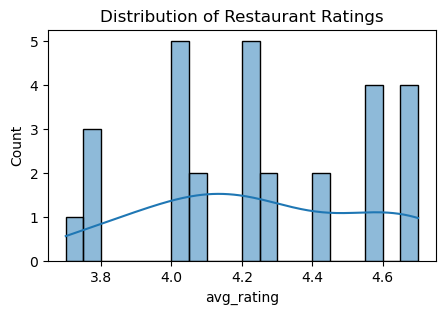

In [85]:
plt.figure(figsize=(5,3))
sns.histplot(df['avg_rating'], bins=20, kde=True)
plt.title("Distribution of Restaurant Ratings")

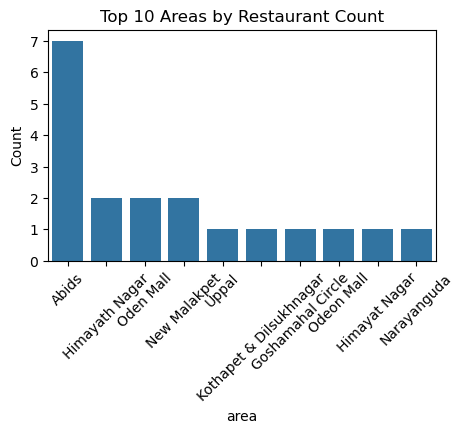

In [87]:
plt.figure(figsize=(5,3))
area_counts = df['area'].value_counts().head(10)
sns.barplot(x=area_counts.index, y=area_counts.values)
plt.title("Top 10 Areas by Restaurant Count")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

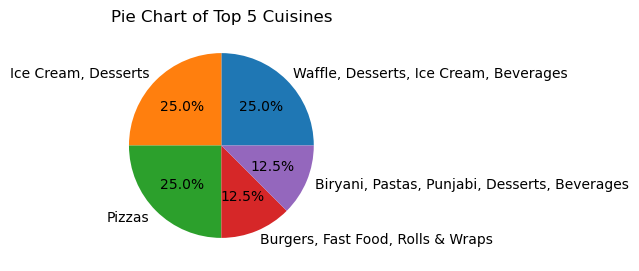

In [89]:
plt.figure(figsize=(6,3))
df['cuisines'].value_counts().head(5).plot.pie(autopct="%1.1f%%")
plt.title("Pie Chart of Top 5 Cuisines")
plt.ylabel("")
plt.show()

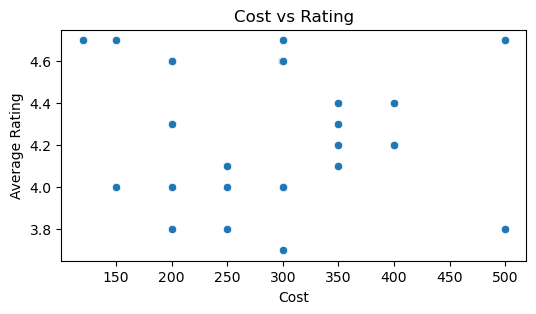

In [91]:
plt.figure(figsize=(6,3))
sns.scatterplot(x='cost_for_two', y='avg_rating', data=df)
plt.title("Cost vs Rating")
plt.xlabel("Cost")
plt.ylabel("Average Rating")
plt.show()

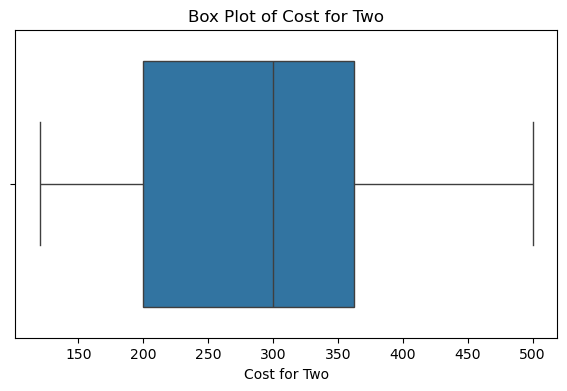

In [93]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['cost_for_two'])
plt.title("Box Plot of Cost for Two")
plt.xlabel("Cost for Two")
plt.show()